<a href="https://colab.research.google.com/github/hanidew/WIE3007-DMW-GroupProject/blob/aliya's-LR/DMW_GA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries from Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    recall_score
)

# LOAD AND INSPEC

In [5]:
# ==========================================
# STEP 1: Load and Inspect Data
# ==========================================

# from google.colab import drive
# drive.mount('/content/drive')

# Load the dataset
filename = '/content/synthetic_data_cleaned_feature_engineered.csv'
df = pd.read_csv(filename, sep='|')

print("✅ Data Loaded Successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

✅ Data Loaded Successfully!
Shape: (1091, 13)
Columns: ['Customer_ID', 'Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term_Months', 'Loan_Officer_Note', 'Default_Status', 'Occupation', 'Has_Asset', 'Risk_Flag', 'DTI_Ratio', 'Log_Income']


# DATA PREPROCESSING

In [6]:
# 2.1 Drop columns that are not useful for prediction
# Customer_ID is identifier, Loan_Officer_Note is text
df_clean = df.drop(columns=['Customer_ID', 'Loan_Officer_Note'])

# 2.2 One-Hot Encoding for 'Occupation' (categorical variable)
df_clean = pd.get_dummies(df_clean, columns=['Occupation'], drop_first=True)

# 2.3 Has_Asset is already 0/1, so no mapping needed
# But let's verify it's numeric
if df_clean['Has_Asset'].dtype == 'object':
    asset_mapping = {'Yes': 1, 'No': 0, 1: 1, 0: 0}
    df_clean['Has_Asset'] = df_clean['Has_Asset'].map(asset_mapping)

# Ensure no NaNs in target variable
df_clean.dropna(subset=['Default_Status'], inplace=True)

# 2.4 Define Features (X) and Target (y)
X = df_clean.drop(columns=['Default_Status'])
y = df_clean['Default_Status'].astype(int)

print(f"\n✅ Features: {X.columns.tolist()}")
print(f"✅ Target distribution:\n{y.value_counts()}")

# 2.5 Split Data into Training and Testing Sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2.6 Feature Scaling (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data Preprocessing Complete.")


✅ Features: ['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term_Months', 'Has_Asset', 'Risk_Flag', 'DTI_Ratio', 'Log_Income', 'Occupation_Education', 'Occupation_Medical', 'Occupation_Other', 'Occupation_Real Estate', 'Occupation_Retired', 'Occupation_Service', 'Occupation_Student', 'Occupation_Tech', 'Occupation_Trade']
✅ Target distribution:
Default_Status
0    630
1    461
Name: count, dtype: int64
✅ Data Preprocessing Complete.


# TRAIN

In [10]:
# Initialize the Logistic Regression model
# max_iter increased to ensure convergence
# class_weight='balanced' helps with imbalanced data
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'  # Helps with imbalanced classes
)

# Handle any potential NaNs in training data
nan_rows = np.isnan(X_train_scaled).any(axis=1)
if nan_rows.any():
    X_train_cleaned = X_train_scaled[~nan_rows]
    y_train_cleaned = y_train.iloc[~nan_rows]
    print(f"⚠️ Warning: Removed {np.sum(nan_rows)} rows containing NaN values from training data.")
else:
    X_train_cleaned = X_train_scaled
    y_train_cleaned = y_train

# Train the model
lr_model.fit(X_train_cleaned, y_train_cleaned)

print("✅ Model Training Complete.")

✅ Model Training Complete.


# EVALUATE TRAINING SET

In [12]:
from sklearn.metrics import precision_score

print("\n" + "="*50)
print("LOGISTIC REGRESSION MODEL PERFORMANCE ON TRAINING DATA")
print("="*50)

# Make predictions on the training set
y_train_pred = lr_model.predict(X_train_scaled)
y_train_prob = lr_model.predict_proba(X_train_scaled)[:, 1] # Probability for class 1 (Default)

# Calculate core metrics for training set
metric_train_accuracy = accuracy_score(y_train_cleaned, y_train_pred)
metric_train_precision = precision_score(y_train_cleaned, y_train_pred)
metric_train_recall = recall_score(y_train_cleaned, y_train_pred)
metric_train_f1 = f1_score(y_train_cleaned, y_train_pred)
metric_train_auc = roc_auc_score(y_train_cleaned, y_train_prob)

# Print detailed performance metrics
print(f"Accuracy:   {metric_train_accuracy:.4f} ({metric_train_accuracy:.2%})")
print(f"Precision:  {metric_train_precision:.4f} ({metric_train_precision:.2%})")
print(f"Recall:     {metric_train_recall:.4f} ({metric_train_recall:.2%})")
print(f"F1-Score:   {metric_train_f1:.4f}")
print(f"ROC-AUC:    {metric_train_auc:.4f}")

print("\n" + "-"*50)
print("CLASSIFICATION REPORT (TRAINING SET)")
print("-"*50)
print(classification_report(y_train_cleaned, y_train_pred, target_names=['Paid (0)', 'Default (1)']))


LOGISTIC REGRESSION MODEL PERFORMANCE ON TRAINING DATA
Accuracy:   0.8773 (87.73%)
Precision:  0.8967 (89.67%)
Recall:     0.8016 (80.16%)
F1-Score:   0.8465
ROC-AUC:    0.9061

--------------------------------------------------
CLASSIFICATION REPORT (TRAINING SET)
--------------------------------------------------
              precision    recall  f1-score   support

    Paid (0)       0.87      0.93      0.90       504
 Default (1)       0.90      0.80      0.85       368

    accuracy                           0.88       872
   macro avg       0.88      0.87      0.87       872
weighted avg       0.88      0.88      0.88       872



# EVALUATION AND METRICS

In [13]:
# Make predictions on the test set
y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]  # Probability for ROC-AUC

# Calculate core metrics
metric_accuracy = accuracy_score(y_test, y_pred)
metric_recall = recall_score(y_test, y_pred)
metric_f1 = f1_score(y_test, y_pred)
metric_auc = roc_auc_score(y_test, y_prob)

# Get feature importance (coefficients)
feature_names = X.columns
coefficients = lr_model.coef_[0]

# Create a Series for feature importance (absolute values)
feature_importance_series = pd.Series(np.abs(coefficients), index=feature_names)
top_features = feature_importance_series.nlargest(5)

# Format the top features into a string
top_features_str = "\n".join([f"- {name}: {value:.4f}" for name, value in top_features.items()])

# Print Core Metrics
print("\n" + "="*40)
print("LOGISTIC REGRESSION MODEL PERFORMANCE")
print("="*40)
print(f"Accuracy:  {metric_accuracy:.4f}")
print(f"Recall:    {metric_recall:.4f} (Crucial for catching defaulters)")
print(f"F1-Score:  {metric_f1:.4f} (Balance of Precision/Recall)")
print(f"ROC-AUC:   {metric_auc:.4f}")
print("\nTop 5 Most Important Features:")
print(top_features_str)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Paid', 'Default']))



LOGISTIC REGRESSION MODEL PERFORMANCE
Accuracy:  0.8265
Recall:    0.7097 (Crucial for catching defaulters)
F1-Score:  0.7765 (Balance of Precision/Recall)
ROC-AUC:   0.8972

Top 5 Most Important Features:
- DTI_Ratio: 1.9516
- Risk_Flag: 1.7054
- Has_Asset: 0.3327
- Loan_Amount: 0.2471
- Credit_Score: 0.2355

Classification Report:

              precision    recall  f1-score   support

        Paid       0.81      0.91      0.86       126
     Default       0.86      0.71      0.78        93

    accuracy                           0.83       219
   macro avg       0.83      0.81      0.82       219
weighted avg       0.83      0.83      0.82       219



# VISUALISATIONS


GENERATING VISUALIZATIONS


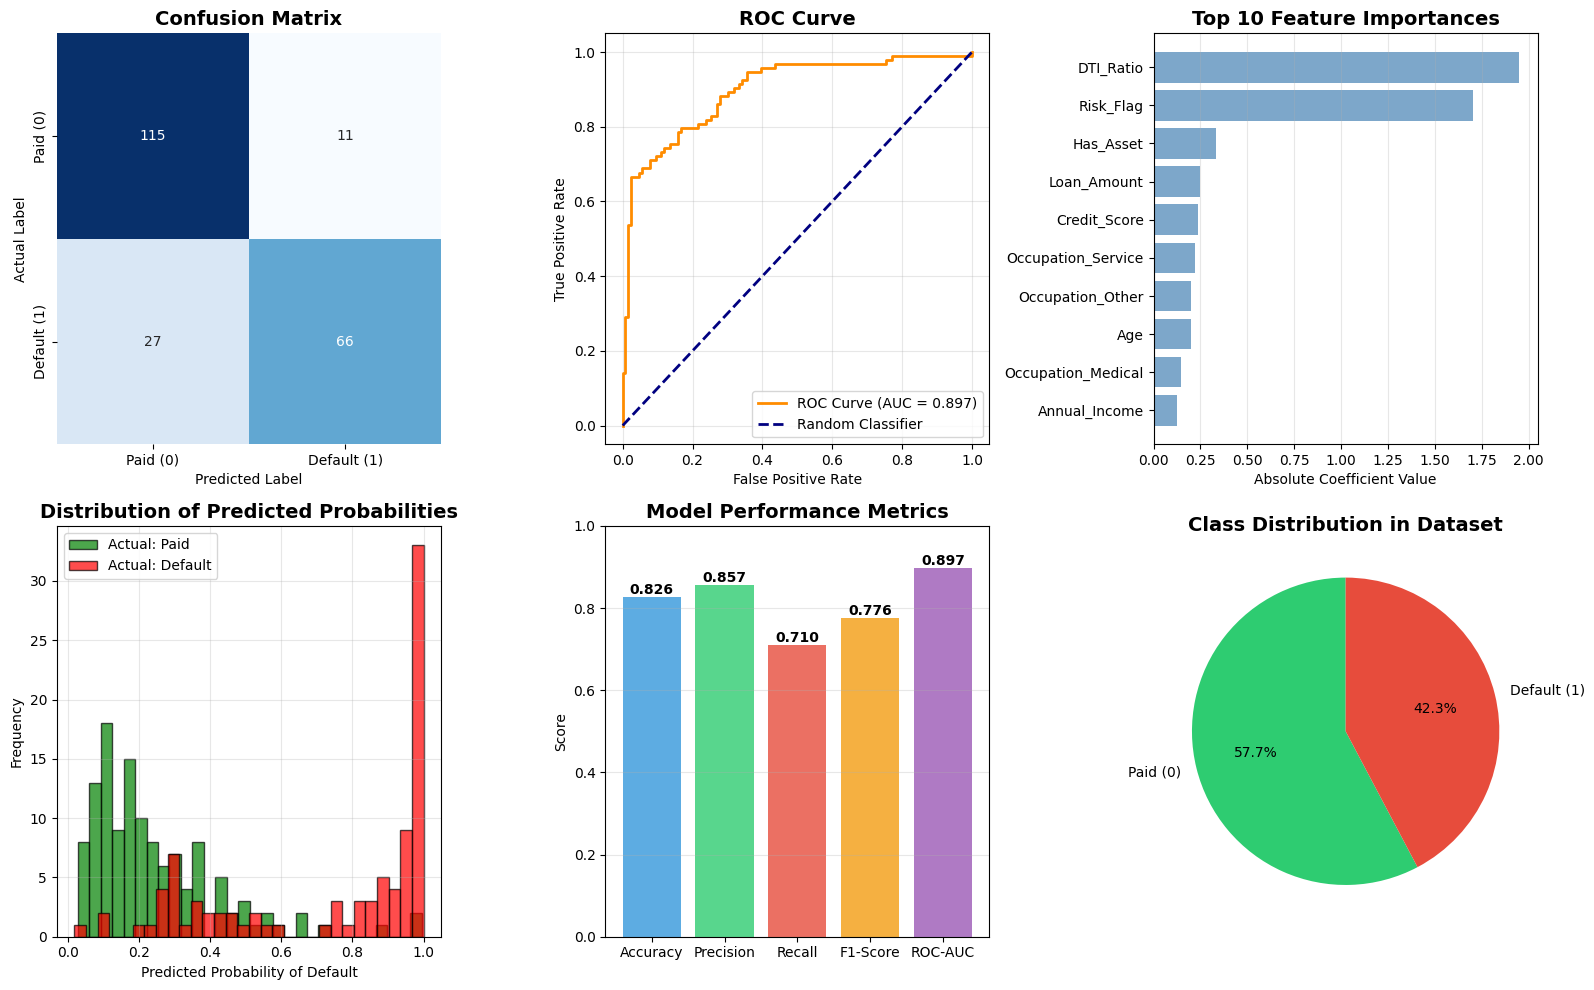

✅ Visualizations Generated.


In [15]:
print("\n" + "="*50)
print("GENERATING VISUALIZATIONS")
print("="*50)

# Calculate metric_precision for the test set, as it was missing from previous calculations
# This ensures all metrics for the bar chart are defined.
metric_precision = precision_score(y_test, y_pred)

# Create a comprehensive visualization
fig = plt.figure(figsize=(16, 10))

# 5.1 Confusion Matrix
ax1 = plt.subplot(2, 3, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1)
ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('Actual Label')
ax1.set_xticklabels(['Paid (0)', 'Default (1)'])
ax1.set_yticklabels(['Paid (0)', 'Default (1)'])

# 5.2 ROC Curve
ax2 = plt.subplot(2, 3, 2)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
ax2.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {metric_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

# 5.3 Feature Importance (Top 10)
ax3 = plt.subplot(2, 3, 3)
# Corrected: Use feature_importance_series and get nlargest(10)
top_10_features_plot = feature_importance_series.nlargest(10)
# Since feature_importance_series contains absolute values, using a single color is appropriate.
ax3.barh(top_10_features_plot.index, top_10_features_plot.values, color='steelblue', alpha=0.7)
ax3.set_xlabel('Absolute Coefficient Value')
ax3.set_title('Top 10 Feature Importances', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')
ax3.invert_yaxis() # Display largest at the top

# 5.4 Prediction Distribution
ax4 = plt.subplot(2, 3, 4)
ax4.hist(y_prob[y_test == 0], bins=30, alpha=0.7, label='Actual: Paid', color='green', edgecolor='black')
ax4.hist(y_prob[y_test == 1], bins=30, alpha=0.7, label='Actual: Default', color='red', edgecolor='black')
ax4.set_xlabel('Predicted Probability of Default')
ax4.set_ylabel('Frequency')
ax4.set_title('Distribution of Predicted Probabilities', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5.5 Performance Metrics Bar Chart
ax5 = plt.subplot(2, 3, 5)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrics_values = [metric_accuracy, metric_precision, metric_recall, metric_f1, metric_auc]
bars = ax5.bar(metrics_names, metrics_values, color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'], alpha=0.8)
ax5.set_ylabel('Score')
ax5.set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
ax5.set_ylim(0, 1)
ax5.grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.3f}',
             ha='center', va='bottom', fontweight='bold')

# 5.6 Class Distribution
ax6 = plt.subplot(2, 3, 6)
class_counts = y.value_counts()
ax6.pie(class_counts.values, labels=['Paid (0)', 'Default (1)'],
        autopct='%1.1f%%', startangle=90, colors=['#2ecc71', '#e74c3c'])
ax6.set_title('Class Distribution in Dataset', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Visualizations Generated.")

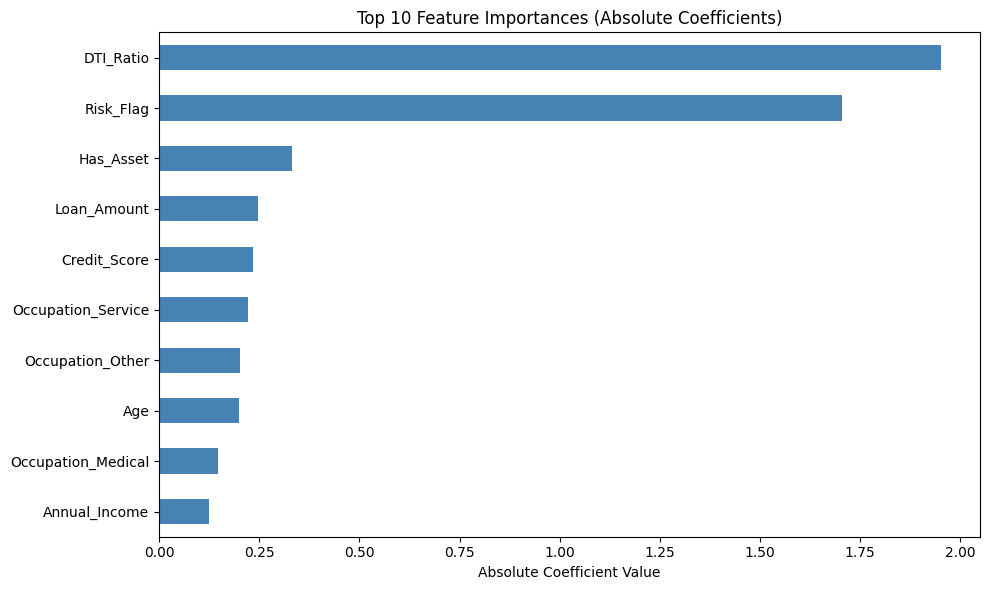

In [16]:
# ==========================================
# STEP 6: Feature Importance Visualization
# ==========================================

plt.figure(figsize=(10, 6))
top_10_features = feature_importance_series.sort_values().tail(10)
top_10_features.plot(kind='barh', color='steelblue')
plt.title('Top 10 Feature Importances (Absolute Coefficients)')
plt.xlabel('Absolute Coefficient Value')
plt.tight_layout()
plt.show()

# INTERPRETATION

In [17]:
# ==========================================
# STEP 7: Display Coefficient Interpretation
# ==========================================

print("\n" + "="*40)
print("COEFFICIENT INTERPRETATION")
print("="*40)
print("Positive coefficients → Increase default probability")
print("Negative coefficients → Decrease default probability")
print("\nTop 5 Positive Predictors of Default:")
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)
print(coef_df.head())
print("\nTop 5 Negative Predictors of Default:")
print(coef_df.tail())


COEFFICIENT INTERPRETATION
Positive coefficients → Increase default probability
Negative coefficients → Decrease default probability

Top 5 Positive Predictors of Default:
               Feature  Coefficient
7            DTI_Ratio     1.951612
6            Risk_Flag     1.705394
2         Credit_Score     0.235483
0                  Age     0.200396
10  Occupation_Medical     0.146631

Top 5 Negative Predictors of Default:
               Feature  Coefficient
17    Occupation_Trade    -0.083994
11    Occupation_Other    -0.201903
14  Occupation_Service    -0.222424
3          Loan_Amount    -0.247055
5            Has_Asset    -0.332691


# HYPERTUNE

In [41]:
import time
from sklearn.metrics import make_scorer, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

print("\n" + "="*60)
print("🔧 STARTING HYPERPARAMETER TUNING WITH GRIDSEARCHCV")
print("="*60)

# Define parameter grid to search
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength
    'penalty': ['l1', 'l2', 'elasticnet'],  # Regularization type
    'solver': ['saga'],  # Solver that supports all penalties
    'class_weight': ['balanced', None],  # Handle imbalanced data
    'max_iter': [1000, 2000],  # Maximum iterations
    'l1_ratio': [0.5]  # For elasticnet (only used if penalty='elasticnet')
}

# Create base model
base_model = LogisticRegression(random_state=42)

# Define custom scorer (prioritize recall for catching defaults)
recall_scorer = make_scorer(recall_score)

# Initialize GridSearchCV
# cv=5 means 5-fold cross-validation
# n_jobs=-1 uses all CPU cores
print("\n⏳ This may take a few minutes...")
start_time = time.time()

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='roc_auc',  # Optimize for ROC-AUC
    n_jobs=-1,  # Use all available cores
    verbose=1,  # Show progress
    return_train_score=True
)

# Fit GridSearchCV
grid_search.fit(X_train_cleaned, y_train_cleaned)

end_time = time.time()
training_time = end_time - start_time


🔧 STARTING HYPERPARAMETER TUNING WITH GRIDSEARCHCV

⏳ This may take a few minutes...
Fitting 5 folds for each of 72 candidates, totalling 360 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


In [45]:
print(f"Training time: {training_time:.2f} seconds")
print(f"\nBest Parameters Found:")
for param, value in grid_search.best_params_.items():
    print(f"   • {param}: {value}")

print(f"\nBest Cross-Validation ROC-AUC Score: {grid_search.best_score_:.4f}")

# Get top 5 parameter combinations
results_df = pd.DataFrame(grid_search.cv_results_)
top_5_results = results_df.nsmallest(5, 'rank_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
]

print("\nTop 5 Parameter Combinations:")
for idx, row in top_5_results.iterrows():
    print(f"\nRank {int(row['rank_test_score'])}:")
    print(f"   Score: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")
    print(f"   Params: {row['params']}")

# Get the best model
best_model = grid_search.best_estimator_

Training time: 14.70 seconds

Best Parameters Found:
   • C: 0.1
   • class_weight: None
   • l1_ratio: 0.5
   • max_iter: 1000
   • penalty: l1
   • solver: saga

Best Cross-Validation ROC-AUC Score: 0.8967

Top 5 Parameter Combinations:

Rank 1:
   Score: 0.8967 (±0.0221)
   Params: {'C': 0.1, 'class_weight': None, 'l1_ratio': 0.5, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}

Rank 1:
   Score: 0.8967 (±0.0221)
   Params: {'C': 0.1, 'class_weight': None, 'l1_ratio': 0.5, 'max_iter': 2000, 'penalty': 'l1', 'solver': 'saga'}

Rank 3:
   Score: 0.8966 (±0.0215)
   Params: {'C': 0.1, 'class_weight': 'balanced', 'l1_ratio': 0.5, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}

Rank 3:
   Score: 0.8966 (±0.0215)
   Params: {'C': 0.1, 'class_weight': 'balanced', 'l1_ratio': 0.5, 'max_iter': 2000, 'penalty': 'l1', 'solver': 'saga'}

Rank 5:
   Score: 0.8956 (±0.0204)
   Params: {'C': 0.1, 'class_weight': 'balanced', 'l1_ratio': 0.5, 'max_iter': 1000, 'penalty': 'elasticnet', 'so

In [47]:
# Evaluate Best Model

print("EVALUATING BEST MODEL ON TEST SET")

# Make predictions
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
metric_accuracy = accuracy_score(y_test, y_pred)
metric_recall = recall_score(y_test, y_pred)
metric_f1 = f1_score(y_test, y_pred)
metric_auc = roc_auc_score(y_test, y_prob)

print(f"\nTest Set Performance:")
print(f"   Accuracy:  {metric_accuracy:.4f}")
print(f"   Recall:    {metric_recall:.4f} (Crucial for catching defaulters)")
print(f"   F1-Score:  {metric_f1:.4f}")
print(f"   ROC-AUC:   {metric_auc:.4f}")

# Get feature importance
all_coefficients = best_model.coef_[0]
# Corrected: Use feature names from the original DataFrame X
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': all_coefficients,
    'Abs_Coefficient': np.abs(all_coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance_df.head(10)[['Feature', 'Coefficient']].to_string())

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Paid', 'Default']))

EVALUATING BEST MODEL ON TEST SET

Test Set Performance:
   Accuracy:  0.8402
   Recall:    0.6774 (Crucial for catching defaulters)
   F1-Score:  0.7826
   ROC-AUC:   0.8956

Top 10 Most Important Features:
               Feature  Coefficient
6            Risk_Flag     1.495552
7            DTI_Ratio     1.461565
5            Has_Asset    -0.203618
0                  Age     0.162368
10  Occupation_Medical     0.107900
2         Credit_Score     0.094383
14  Occupation_Service    -0.075065
11    Occupation_Other    -0.054139
4     Loan_Term_Months     0.053382
13  Occupation_Retired     0.047103

Classification Report:

              precision    recall  f1-score   support

        Paid       0.80      0.96      0.87       126
     Default       0.93      0.68      0.78        93

    accuracy                           0.84       219
   macro avg       0.86      0.82      0.83       219
weighted avg       0.85      0.84      0.83       219



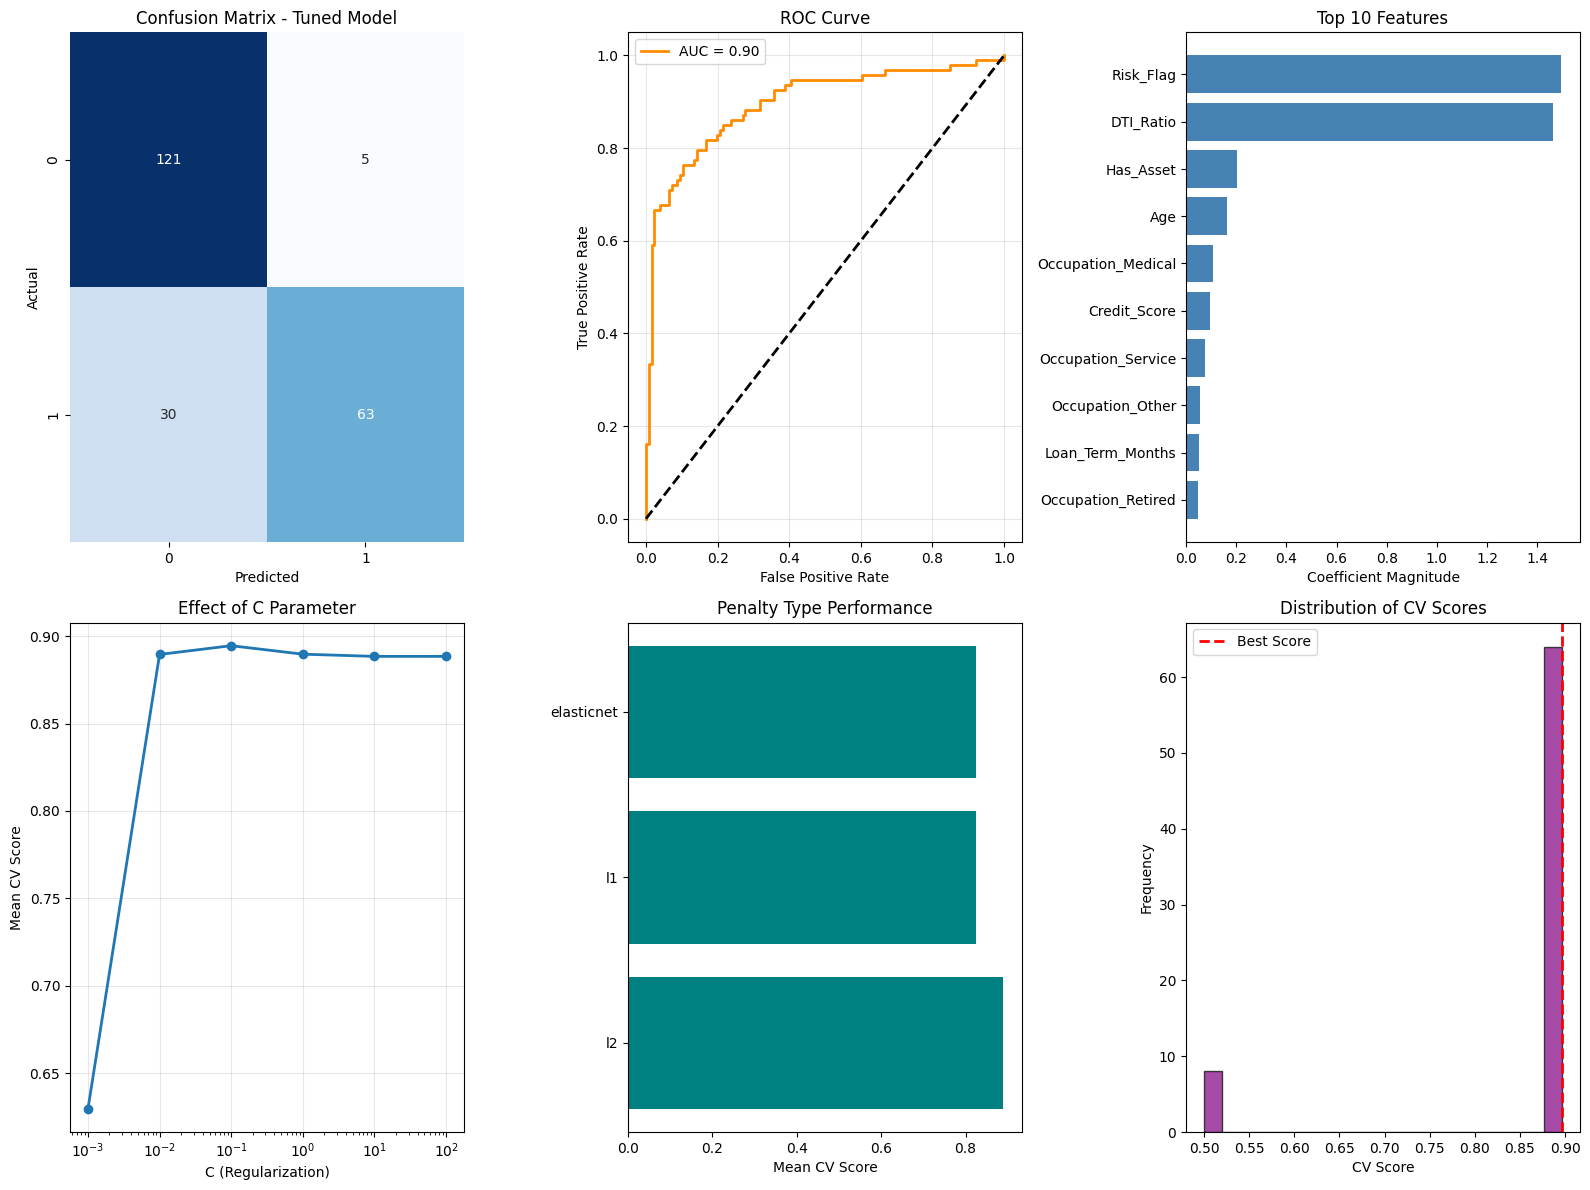

In [48]:
fig = plt.figure(figsize=(16, 12))

# 8.1 Confusion Matrix
plt.subplot(2, 3, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Tuned Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# 8.2 ROC Curve
plt.subplot(2, 3, 2)
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {metric_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)

# 8.3 Feature Importance
plt.subplot(2, 3, 3)
top_10 = feature_importance_df.head(10)
colors = ['steelblue' if not f.startswith('text_') else 'coral' for f in top_10['Feature']]
plt.barh(range(len(top_10)), top_10['Abs_Coefficient'], color=colors)
plt.yticks(range(len(top_10)), top_10['Feature'])
plt.xlabel('Coefficient Magnitude')
plt.title('Top 10 Features')
plt.gca().invert_yaxis()

# 8.4 Hyperparameter Comparison - C parameter
plt.subplot(2, 3, 4)
c_results = results_df.groupby('param_C')['mean_test_score'].mean()
plt.plot(c_results.index, c_results.values, marker='o', linewidth=2)
plt.xscale('log')
plt.xlabel('C (Regularization)')
plt.ylabel('Mean CV Score')
plt.title('Effect of C Parameter')
plt.grid(alpha=0.3)

# 8.5 Penalty Type Comparison
plt.subplot(2, 3, 5)
penalty_results = results_df.groupby('param_penalty')['mean_test_score'].mean().sort_values()
plt.barh(range(len(penalty_results)), penalty_results.values, color='teal')
plt.yticks(range(len(penalty_results)), penalty_results.index)
plt.xlabel('Mean CV Score')
plt.title('Penalty Type Performance')
plt.gca().invert_yaxis()

# 8.6 Cross-validation Score Distribution
plt.subplot(2, 3, 6)
plt.hist(results_df['mean_test_score'], bins=20, color='purple', alpha=0.7, edgecolor='black')
plt.axvline(grid_search.best_score_, color='red', linestyle='--', linewidth=2, label='Best Score')
plt.xlabel('CV Score')
plt.ylabel('Frequency')
plt.title('Distribution of CV Scores')
plt.legend()

plt.tight_layout()
plt.show()


In [49]:
from sklearn.model_selection import cross_val_score

print("HYPERPARAMETER TUNING SUMMARY")

print(f"\n Total parameter combinations tested: {len(results_df)}")
print(f"Best CV score improvement: {grid_search.best_score_:.4f}")
print(f"  Optimal regularization (C): {grid_search.best_params_['C']}")
print(f"  Optimal penalty: {grid_search.best_params_['penalty']}")
print(f"  Optimal class_weight: {grid_search.best_params_['class_weight']}")

# Cross-validation scores for best model
cv_scores = cross_val_score(best_model, X_train_cleaned, y_train_cleaned, cv=5, scoring='roc_auc')
print(f"\n🎯 Cross-validation scores for best model:")
print(f"   Mean: {cv_scores.mean():.4f}")
print(f"   Std:  {cv_scores.std():.4f}")
print(f"   Individual fold scores: {[f'{score:.4f}' for score in cv_scores]}")

print("\n Hyperparameter tuning complete!")

HYPERPARAMETER TUNING SUMMARY

 Total parameter combinations tested: 72
Best CV score improvement: 0.8967
  Optimal regularization (C): 0.1
  Optimal penalty: l1
  Optimal class_weight: None

🎯 Cross-validation scores for best model:
   Mean: 0.8967
   Std:  0.0221
   Individual fold scores: ['0.8829', '0.9205', '0.9113', '0.8602', '0.9085']

 Hyperparameter tuning complete!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


# LLM INSIGHT

In [51]:
import google.generativeai as genai

# ==============================
# 1. CONFIGURE GEMINI
# ==============================
# Replace with your actual API key
from google.colab import userdata

api_key = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=api_key)

# Note: As of early 2026, gemini-2.5-flash is a valid model name.
model_name = "gemini-2.5-flash"

In [52]:
metrics = {
    "accuracy": metric_accuracy,
    "recall": metric_recall,
    "f1": metric_f1,
    "roc_auc": metric_auc
}

In [61]:
prompt = f"""
You are a senior data science consultant.
I trained a Logistic Regression on a financial dataset to predict loan defaults.
Here are the performance metrics:

- Accuracy: {metrics['accuracy']:.2%}
- Recall: {metrics['recall']:.2%}
- F1-score: {metrics['f1']:.2%}
- ROC-AUC: {metrics['roc_auc']:.2%}

Please provide:
1. Summary of model performance
2. Key strengths and weaknesses
3. Suggestions for improvement (hyperparameters, architecture, data)
4. Interpretation of feature importance for Logistic Regression
5. Any potential risks or biases (financial context)
Format your response in a clear, structured, and summarised style.
"""

In [62]:
# In the google-generativeai library, we use GenerativeModel
model = genai.GenerativeModel(
    model_name=model_name,
    generation_config={
        "temperature": 0.2,
        "max_output_tokens": 10000,
    }
)

In [63]:
# ==============================
# 3. GENERATION SETTINGS
# ==============================
# Increase max_output_tokens to allow for a full report
generation_config = {
    "max_output_tokens": 20408,  # Increased from default
    "temperature": 0.7,
}

# Use the config in the generate_content call
response = model.generate_content(prompt, generation_config=generation_config)

# ==============================
# 4. OUTPUT
# ==============================
if response.text:
    print(response.text)
else:
    # If it's empty, it might be a safety filter block
    print("No response. Check response.prompt_feedback or safety settings.")

Here's a structured summary and analysis of your Logistic Regression model for loan default prediction:

---

### Logistic Regression Model Performance Review: Loan Default Prediction

**1. Summary of Model Performance**

Your Logistic Regression model demonstrates a strong overall ability to distinguish between defaulting and non-defaulting loans, as indicated by its high ROC-AUC. It achieves a good general accuracy and a reasonable balance between precision and recall (F1-score). However, there is a notable area for improvement in identifying a significant portion of actual defaulting loans.

**2. Key Strengths and Weaknesses**

*   **Key Strengths:**
    *   **ROC-AUC (89.56%): Excellent Discriminative Power.** This is the standout metric. It indicates that the model is very good at ranking borrowers by their likelihood of default, meaning it can effectively separate high-risk from low-risk applicants across various decision thresholds. This is crucial for risk management.
    *   *

In [64]:
print("Best Hyperparameters for Logistic Regression:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

Best Hyperparameters for Logistic Regression:
  C: 0.1
  class_weight: None
  l1_ratio: 0.5
  max_iter: 1000
  penalty: l1
  solver: saga
